In [45]:
import os
import sys

repo_url = "https://github.com/chahineNejm/kernels_playground"
repo_name = repo_url.split("/")[-1]
%cd /content
if os.path.exists(repo_name):
    print(f"🗑️ Wiping old '{repo_name}' to clear out local changes...")
    !rm -rf {repo_name}

print(f"📥 Cloning fresh '{repo_name}'...")
!git clone {repo_url}

repo_path = os.path.abspath(repo_name)
if repo_path not in sys.path:
    sys.path.append(repo_path)
%cd {repo_name}

req_file = "first_tests/requirements.txt"
if os.path.exists(req_file):
    print("⚙️ Installing dependencies...")
    !pip install -q -r {req_file}

%load_ext autoreload
%autoreload 2
%cd first_tests

print("\n✅ Fresh setup complete! You are now inside the 'first_tests' folder.")

/content
🗑️ Wiping old 'kernels_playground' to clear out local changes...
📥 Cloning fresh 'kernels_playground'...
Cloning into 'kernels_playground'...
remote: Enumerating objects: 78, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 78 (delta 21), reused 72 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (78/78), 30.44 MiB | 23.42 MiB/s, done.
Resolving deltas: 100% (21/21), done.
/content/kernels_playground
⚙️ Installing dependencies...
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/content/kernels_playground/first_tests

✅ Fresh setup complete! You are now inside the 'first_tests' folder.


In [46]:
import numpy as np
import matplotlib.pyplot as plt

import importlib


# local utils package
from utils.config import DEFAULT_CONFIG
from utils.data import (
    load_gift_dataset, quick_peek, dataset_summary, build_examples,
    normalize_by_history,
)
from utils.kernels import fit_kernel_operator, predict_kernel_operator, rmse, relative_rmse
from utils.viz import (
    plot_series, plot_series_grid, plot_distribution,
    plot_train_test_split, plot_kernel_heatmap,
    plot_residuals, plot_metric_summary,
    plot_predictions_for_domain,
)
from utils.pipeline import train_eval


## Configuration
Override any defaults here.

In [47]:
cfg = {
    **DEFAULT_CONFIG,
    "CONFIGS": {
        "Energy": "electricity_H_long",
        # "Cloud":   "bitbrains_fast_storage_5T_long",
        # "Traffic": "loop_seattle_H_long",
        # "Solar":   "solar_H_long",
    },
    "N_SAMPLES_TO_LOAD": 5000,
    "N_TEST_SAMPLES": 200,
}
cfg

{'DATASET_NAME': 'Salesforce/GiftEvalParquet',
 'CONFIGS': {'Energy': 'electricity_H_long'},
 'N_SAMPLES_TO_LOAD': 5000,
 'N_TEST_SAMPLES': 200,
 'RANDOM_SEED': 0,
 'GAMMA': 0.01,
 'PAIRWISE_MEDIAN_SUBSET': 24,
 'HISTORY_CONTEXT_TO_PLOT': 240,
 'SAVE_FIGURE': True,
 'SHOW_FIGURES': True,
 'OUTPUT_STEM': 'kernel_operator_forecast'}

## Quick dataset exploration
Use these to poke around any config before running the full pipeline.

history: (31464,)  future: (720,)


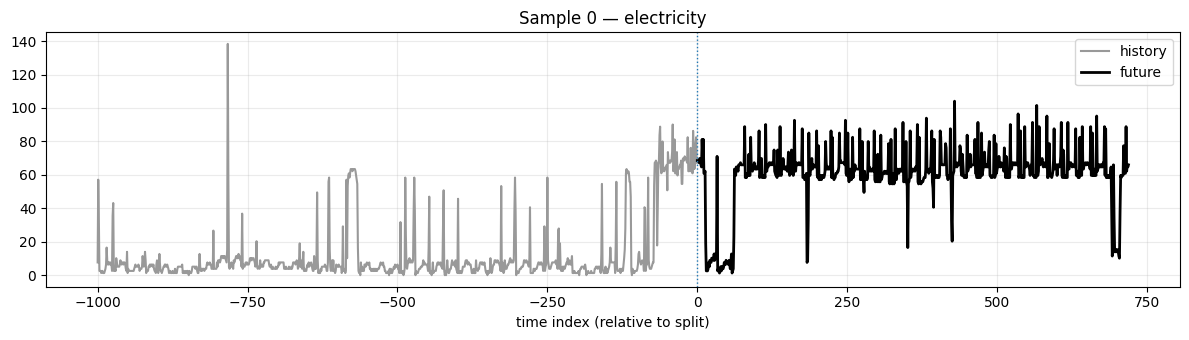

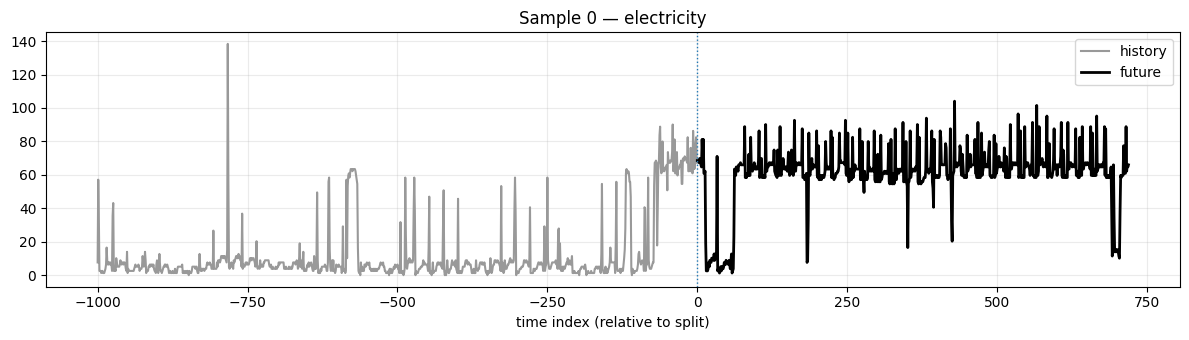

In [48]:
# Peek at one sample
sample = quick_peek(index=0, config="Energy")
print(f"history: {sample['history'].shape}  future: {sample['future'].shape}")
plot_series(sample["history"], sample["future"], title="Sample 0 — electricity", history_context=1000,show=False)

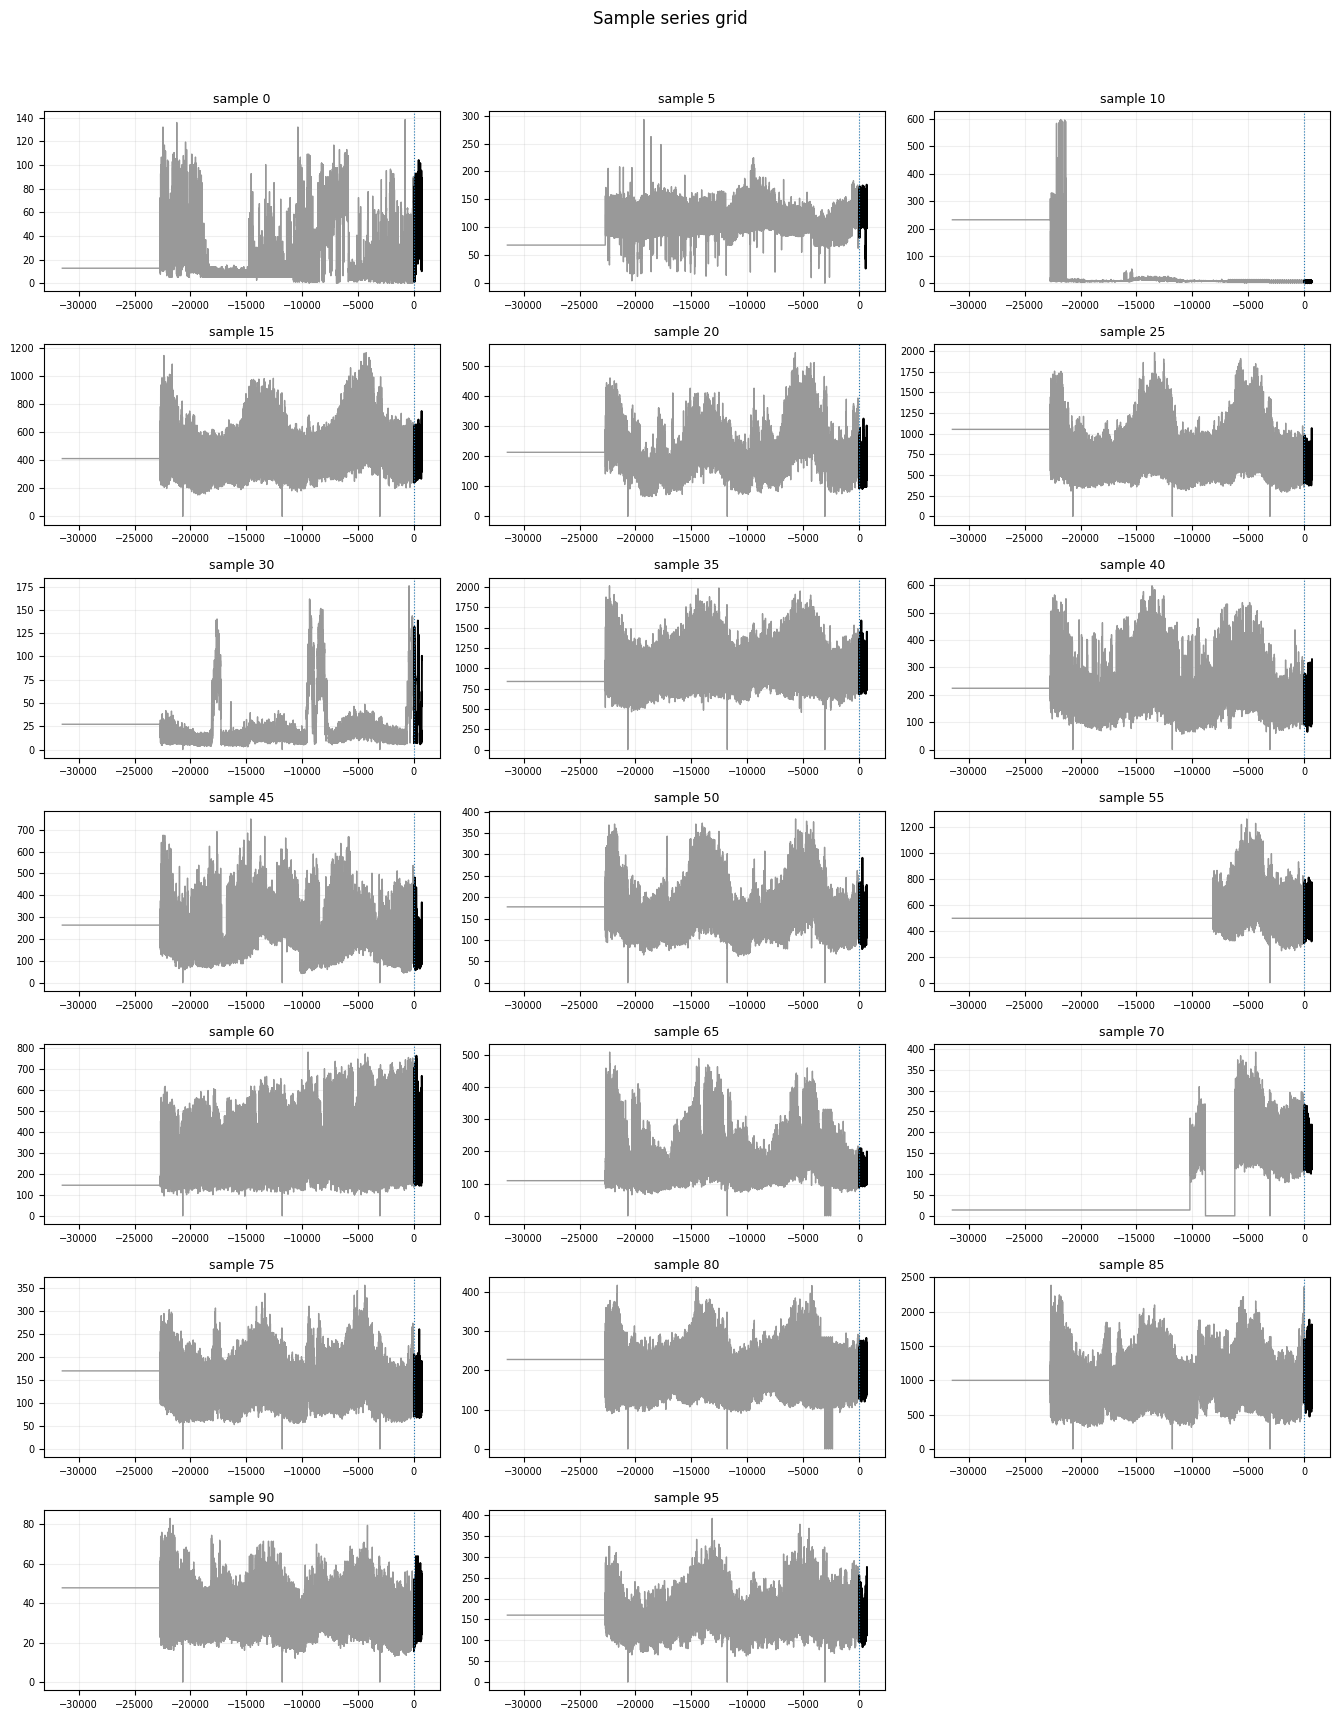

In [49]:
# Grid view of several samples
examples_preview = build_examples(config="Energy", start=0, stop =100 ,step = 5)
plot_series_grid(examples_preview)

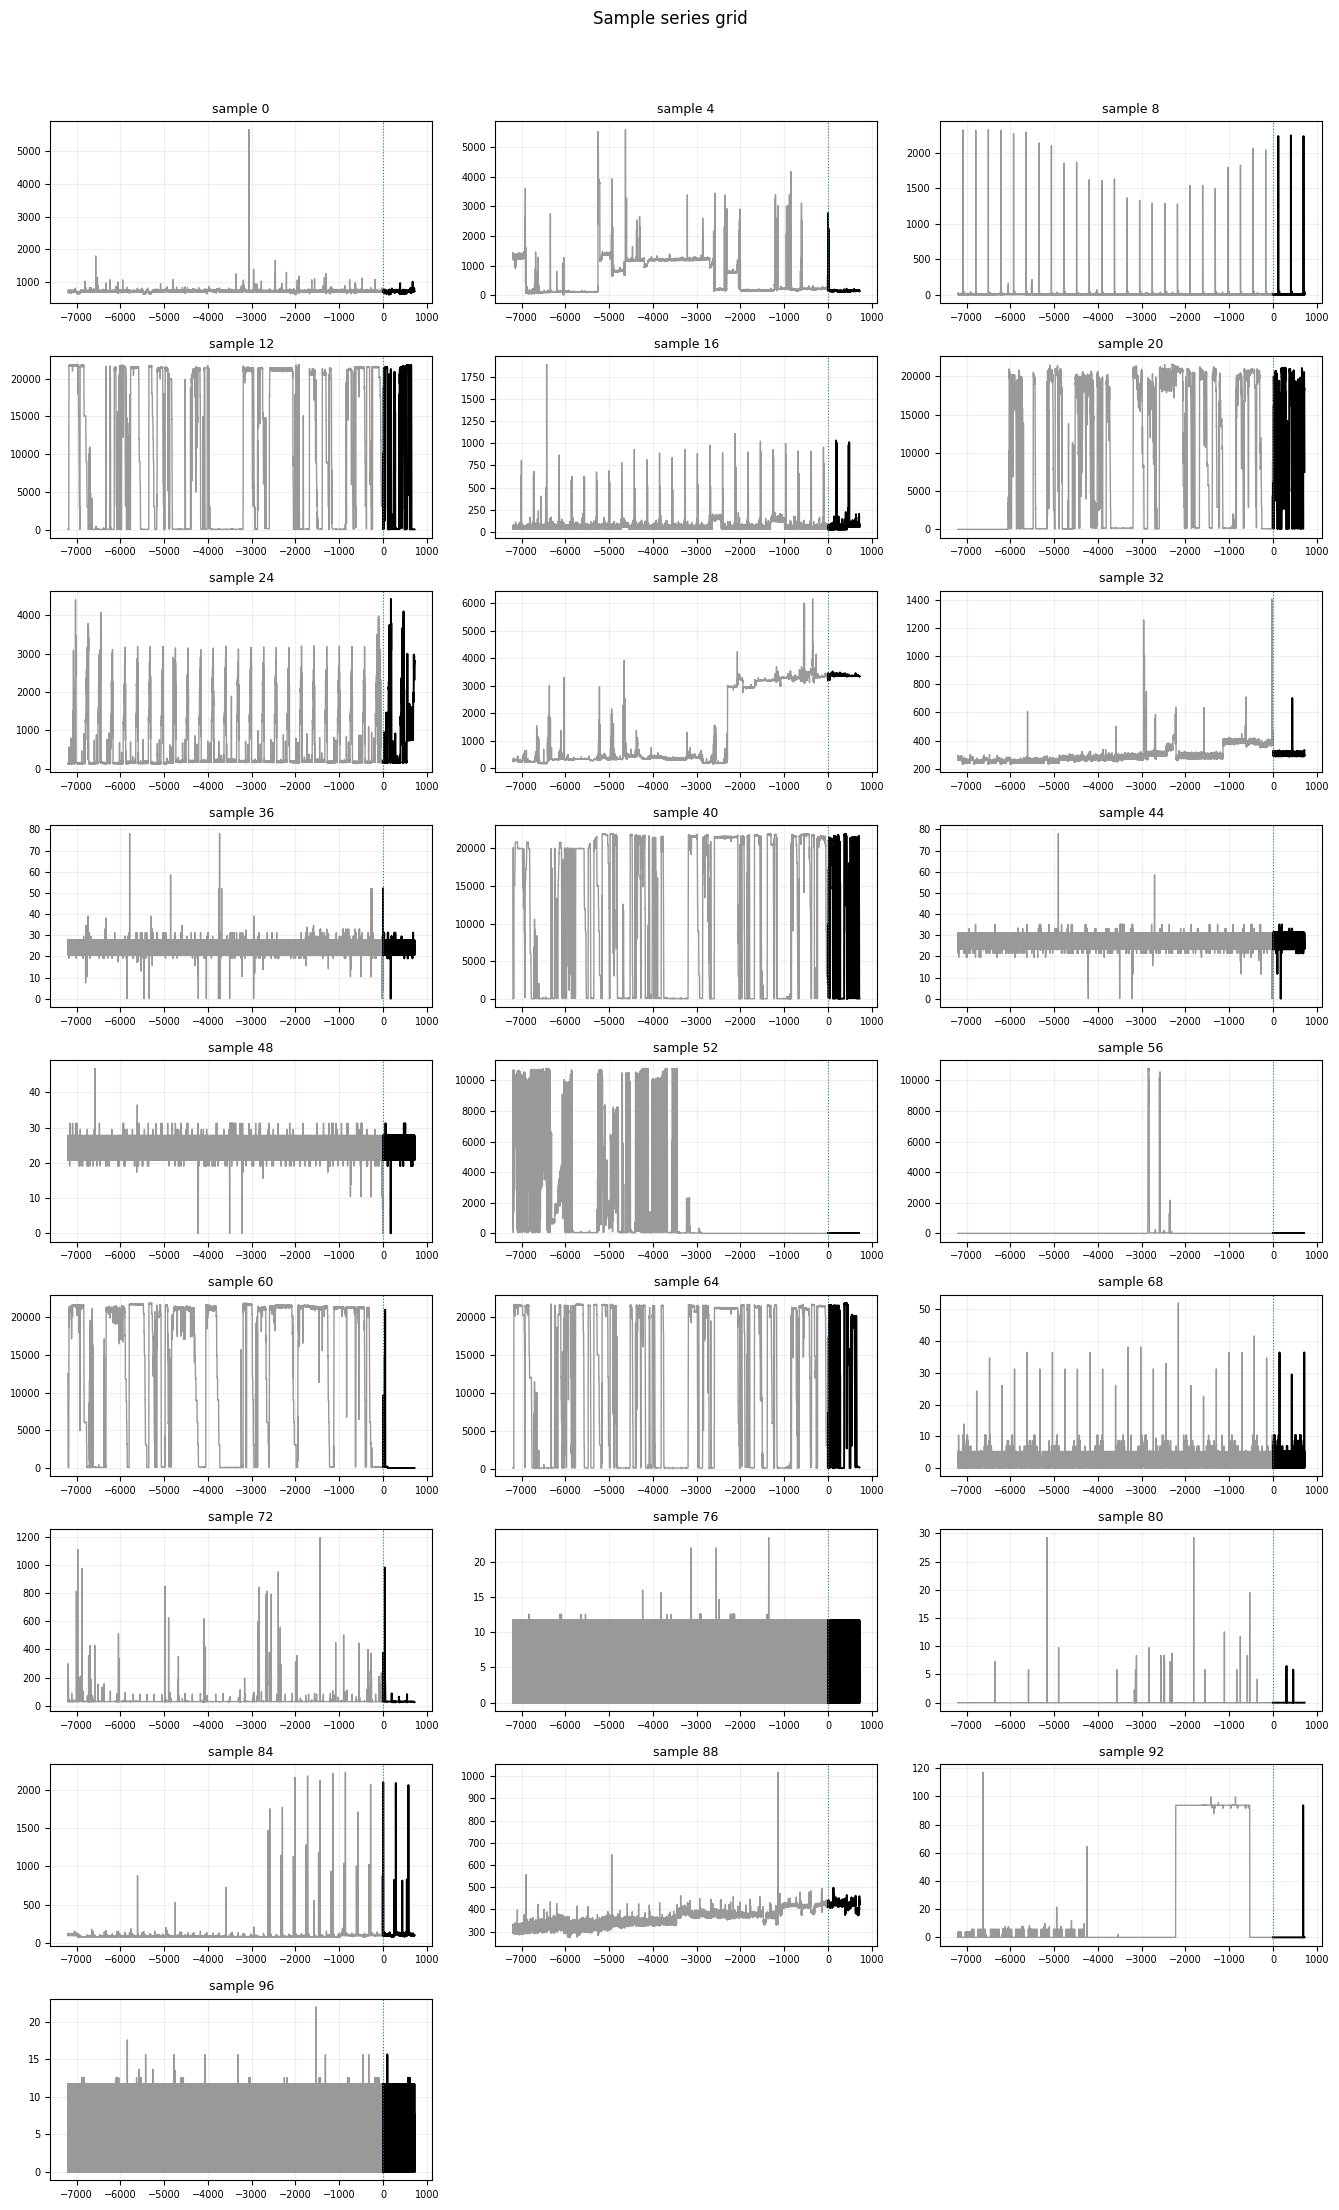

In [50]:
examples_preview = build_examples(config="Cloud", start=0, stop =100 ,step = 4)
plot_series_grid(examples_preview)

## Full kernel‑operator pipeline

In [51]:
from utils.pipeline import train_eval

examples = build_examples("Energy", start=0, stop=1000)

# Mode 1: you pick both sets
result = train_eval(examples, train_indices=range(0, 600), test_indices=range(600, 800))

# Mode 2: you pick train, test = everything else
result = train_eval(examples, train_indices=[0, 5, 10, 15, 20, 50, 100])

# Mode 3: you pick test, train = everything else
result = train_eval(examples, test_indices=[3, 7, 42, 99])

# Mode 4: no indices → random split (old behavior)
result = train_eval(examples, n_test=50)

[Energy] loading electricity_H_long  (rows 0-5000, step 5)
[Energy] split: 170 train, 200 test
[Energy] fitted: l=216.7225, gamma=1.00e-02
[Energy] done - mean relRMSE=0.1949
{'domain': 'Energy', 'config': 'electricity_H_long', 'n_train': 170, 'n_test': 200, 'lengthscale': 216.72248955078686, 'gamma': 0.01, 'mean_rmse': 485.9654309002614, 'mean_relRMSE': 0.194859707704952, 'median_relRMSE': 0.1090119120703687}

[Energy] loading electricity_H_long  (rows 0-5000, step 5)
[Energy] split: 170 train, 200 test
[Energy] fitted: l=216.7225, gamma=1.00e-02
[Energy] done - mean relRMSE=0.1949

[Cloud] loading bitbrains_fast_storage_5T_long  (rows 0-5000, step 5)
[Cloud] split: 800 train, 200 test
[Cloud] fitted: l=119.4234, gamma=1.00e-02
[Cloud] done - mean relRMSE=67.6647

[Traffic] loading loop_seattle_H_long  (rows 0-5000, step 5)


loop_seattle_H_long/train.parquet:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/646 [00:00<?, ? examples/s]

[Traffic] skipped: Not enough samples for Traffic: got 130, need > 200

[Solar] loading solar_H_long  (rows 0-5000, step 5)


solar_H_long/train.parquet:   0%|          | 0.00/1.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/274 [00:00<?, ? examples/s]

[Solar] skipped: Not enough samples for Solar: got 55, need > 200
{'domain': 'Energy', 'config': 'electricity_H_long', 'n_train': 170, 'n_test': 200, 'lengthscale': 216.72248955078686, 'gamma': 0.01, 'mean_rmse': 485.9654309002614, 'mean_relRMSE': 0.194859707704952, 'median_relRMSE': 0.1090119120703687}
{'domain': 'Cloud', 'config': 'bitbrains_fast_storage_5T_long', 'n_train': 800, 'n_test': 200, 'lengthscale': 119.42338737952605, 'gamma': 0.01, 'mean_rmse': 5866.533028689372, 'mean_relRMSE': 67.66468852341235, 'median_relRMSE': 4.716737695441897}
